# 03 · Processing at scale

**Story so far:** the raw review corpus sits in the object store. Sequentially looping
over it (chapter 01's naive pipeline) won't survive contact with real volume. This
chapter enriches **every review in parallel** (with an external "moderation API" in the
loop) and makes the whole thing survive failures, size skew, and slow dependencies.

**Learning goals**

1. Fan out work with `asyncio.gather` and `flyte.map.aio`, and know when to use which
2. Bound parallelism two ways: per-map `concurrency`, and cluster-wide **Union Queues**
3. Configure retries and two-dimensional timeouts (runtime vs queue wait)
4. Recover from OOM by retrying with more memory, in code
5. Checkpoint inside a task with `@flyte.trace`

In [37]:
import asyncio
from typing import List

import flyte

flyte.init_from_config()

env = flyte.TaskEnvironment(
    name="processing",
    resources=flyte.Resources(cpu="1", memory="1Gi"),
)

In [38]:
# 200 synthetic reviews. In a real engagement these rows come from chapter 02's landed corpus.
import random


def make_reviews(n: int, seed: int = 7) -> list:
    rng = random.Random(seed)
    products = ["espresso machine", "trail shoes", "headphones", "air fryer"]
    out = []
    for i in range(n):
        p = rng.choice(products)
        out.append({"id": i, "product": p, "stars": rng.randint(1, 5),
                    "text": f"review {i} about the {p}"})
    return out


REVIEWS = make_reviews(200)
len(REVIEWS)

200

## 1. Fan-out / fan-in

In v2 there is no `@dynamic` and no special map-task construct: fan-out is plain Python.
Two idioms:

- **`asyncio.gather`**: build the coroutines yourself; best for heterogeneous fan-out
  (different tasks, branches).
- **`flyte.map.aio`**: for the same task over a list. It streams results as they finish,
  caps how many run at once (next section), groups the actions in the UI via `group_name`,
  and handles partial failures with `return_exceptions=True`.

Our unit of work is `enrich`: clean one review and add a length feature. It runs on a small
warm pool so 200 of them do not each pay a container cold start. The pool (`ReusePolicy`)
is the subject of [chapter 05](./05-reusable-containers.ipynb); here it just keeps the demos
fast, and each item sleeps briefly to stand in for real work.

In [28]:
from datetime import timedelta

pool = flyte.TaskEnvironment(
    name="enrich_pool",
    image=flyte.Image.from_debian_base(python_version=(3, 12)).with_pip_packages(
        "unionai-reuse>=0.1.15"
    ),
    resources=flyte.Resources(cpu="1", memory="512Mi"),
    reusable=flyte.ReusePolicy(replicas=(2, 4), concurrency=30,
                               scaledown_ttl=timedelta(minutes=5)),
)

# The orchestrator gets its own lightweight env. It calls enrich (in `pool`), so that env
# must be declared with depends_on=[pool] for the run to bundle both (chapter 01 §5).
driver = flyte.TaskEnvironment(
    name="enrich_driver",
    resources=flyte.Resources(cpu="1", memory="1Gi"),
    depends_on=[pool],
)


@pool.task
async def enrich(review: dict) -> dict:
    await asyncio.sleep(10)                    # stand in for real per-item work
    text = review["text"].strip().lower()
    return {**review, "text": text, "n_words": len(text.split())}


@driver.task
async def enrich_all(reviews: List[dict], concurrency: int) -> int:
    done = 0
    async for r in flyte.map.aio(enrich, reviews, concurrency=concurrency,
                                 group_name="enrichment", return_exceptions=True):
        if isinstance(r, Exception):
            raise r
        done += 1
    return done

In [29]:
# Fan out: 200 enrich child actions on the warm pool, grouped under "enrichment" in the UI.
# concurrency=200 lets them all go at once (bounded only by the pool's capacity).
run = flyte.run(enrich_all, reviews=REVIEWS, concurrency=200)
print(run.url)
run.wait()

> Building 2 images...

> Building image flyte for environment enrich_driver

> Building image flyte for environment enrich_pool

✓ Built image for environment enrich_driver: ghcr.io/flyteorg/flyte:py3.12-v2.5.11

✓ Built image for environment enrich_pool: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:flyte-6600116b252d7344315b5b647ae43822

Output()

https://demo.hosted.unionai.cloud/v2/domain/development/project/davide/runs/uw4lhjggzcbls6hfkz8p


Run 'uw4lhjggzcbls6hfkz8p' completed successfully.

### Runs and actions

That call created one **run** (its URL) made of many **actions**:

- A **run** is one execution of `flyte.run(...)`: the whole tree, with its own name and URL.
- An **action** is a single task invocation inside a run. Each is scheduled and tracked on
  its own; on the warm pool several actions share a container.

The run you just launched is shaped like this:

```
run  (the URL above)
└─ a0  enrich_all               root action: the task you called
   ├─ enrich(review 0)          ┐
   ├─ enrich(review 1)          │  200 child actions, one per review,
   ├─ ...                       │  dispatched by flyte.map
   └─ enrich(review 199)        ┘
```

Fan-out is a root action launching many child actions. Bounding parallelism, next, is
about capping how many child actions run at once.

## 2. Bounding parallelism

The fan-out above ran up to the pool's capacity at once. Over 100k reviews, unbounded, that
overwhelms two things before the cluster does: your own driver (it tracks every in-flight
child) and whatever the reviews hit (the rate-limited moderation API). You bound it at two
levels, and they cap different scopes.

**Per fan-out: `flyte.map` `concurrency`.** Caps how many child actions a single map keeps
in flight, inside one run: `flyte.map.aio(enrich, reviews, concurrency=N)`. Run the same
pipeline twice and each run gets its own budget of `concurrency`, so two runs can put
`2 x N` actions on the API at once.

**Cluster-wide: Union Queues.** A **queue** is a control-plane scheduling lane. Tasks that
target it (by name, with `queue="..."`) are admitted through its **global** cap: at most N
actions from the queue run at once across every run and every user. That is what protects a
shared, rate-limited dependency. Unlike an `asyncio.Semaphore` (which lives in one task
process and is gone the moment the pod restarts), the cap is enforced by the platform and
survives across runs. A queue also carries depth (a bounded backlog) and priority.

```
  flyte.map(concurrency=N)             Union queue (cap = N)
  scope: one map, one run              scope: global, across all runs

   run A ─▶ ≤ N in flight               run A ─┐
                                               ├─▶ queue ─▶ ≤ N in flight TOTAL
   run B ─▶ ≤ N in flight               run B ─┘
   two runs: up to 2N at the API        two runs: still ≤ N at the API
```

When both apply to the same actions, the tighter one wins: effective concurrency is
`min(map concurrency, queue cap)`. One wrinkle: the parent action (the orchestrator) holds
a queue slot while it waits for its children, so a cap of N runs about N-1 children at once,
and a cap of 1 would deadlock (the parent takes the only slot). That is why an
action-concurrency cap must be 0 or at least 2.

Set a queue on a `TaskEnvironment`, on a single `@env.task`, at call time with
`.override(queue=...)`, or per run with `flyte.with_runcontext(queue=...)`. Your platform
team creates it and sets the cap, depth, and priority; the how-to is in the
[Union docs](https://www.union.ai/docs/v2/union/api-reference/flyte-cli/#flyte-create-queue).

The two demos below cap the same 200-review fan-out: first at the map level, then through a
queue.

In [ ]:
import time

# Low cap: at most 5 enrich actions run at once. Open the URL and watch ~5 in Running.
t0 = time.perf_counter()
run = flyte.run(enrich_all, reviews=REVIEWS, concurrency=5)
run.wait()
print(f"concurrency=5:  {time.perf_counter() - t0:.0f}s   {run.url}")

# Same 200 items, higher cap: more run at once, so it finishes much sooner.
t0 = time.perf_counter()
run = flyte.run(enrich_all, reviews=REVIEWS, concurrency=25)
run.wait()
print(f"concurrency=25: {time.perf_counter() - t0:.0f}s   {run.url}")

**Expectedly, this run limits the in-flight actions to `5` but if you'd submit another run it would also go with 5 actions at a time, accumulating load on any downstream/upstream system that depens on it**

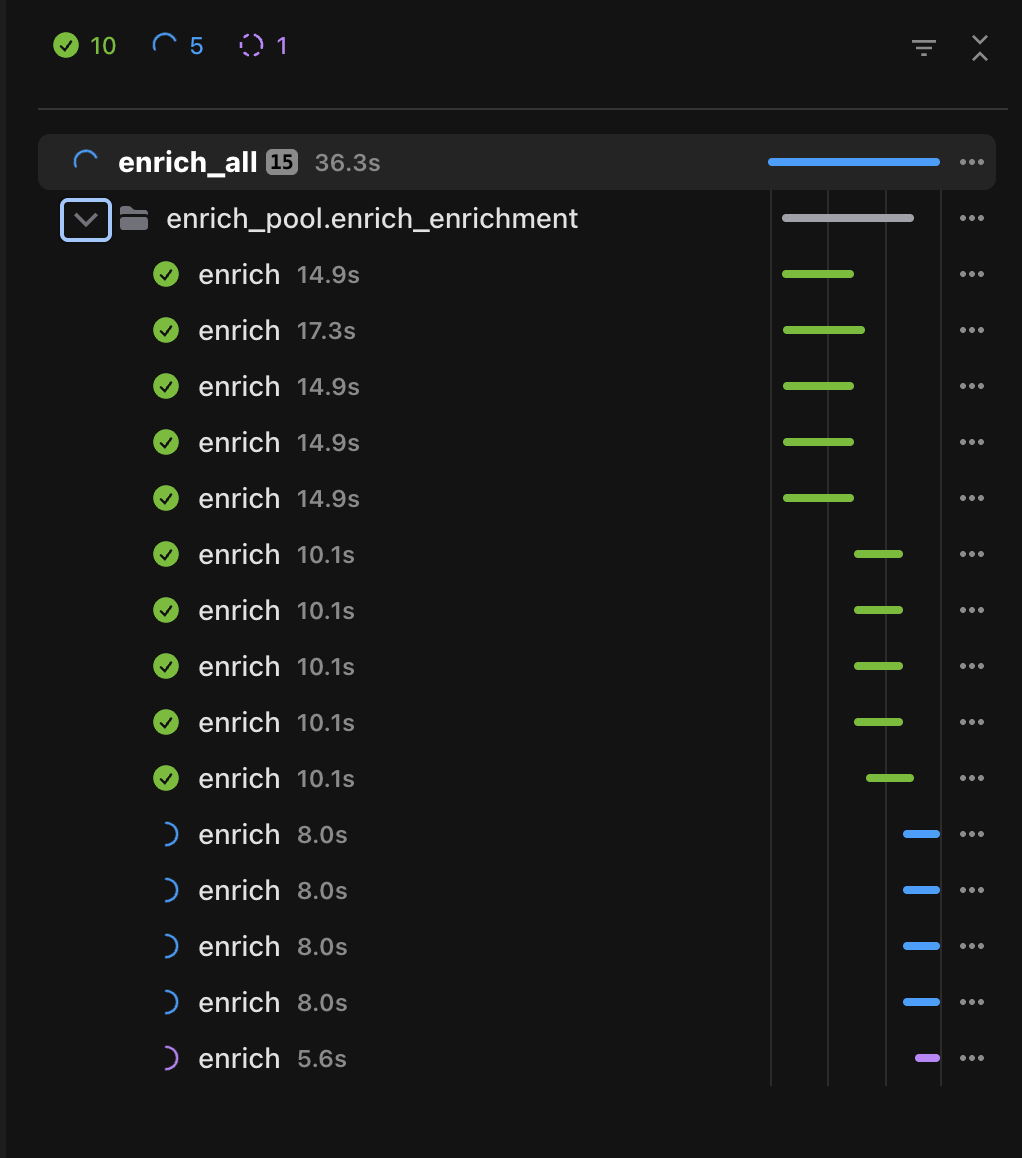

Now, we use a Union Queue to cap concurrency at a global level (it can be scoped to a project or particular cluster):

In [ ]:
# Same fan-out, now through a queue. Set WORKSHOP_QUEUE to a queue that exists on your
# deployment (a name that does not exist fails to schedule, so it defaults to None = skip).
# The map cap is high (50), so a lower queue cap is what you observe: watch at most the
# queue's cap of enrich actions in Running, even though the map would allow 50.
WORKSHOP_QUEUE = "moderation-api"   # e.g. "moderation-api"

if WORKSHOP_QUEUE:
    run = flyte.with_runcontext(queue=WORKSHOP_QUEUE).run(
        enrich_all, reviews=REVIEWS, concurrency=50
    )
    print(run.url)
    run.wait()
    print(run.outputs())
else:
    print("Set WORKSHOP_QUEUE to a queue on your deployment to route this run through it.")

In this case, the run is capped at 20 concurrent actions at any given time, despite the map submitting 50. The remaining portions remain Queued:

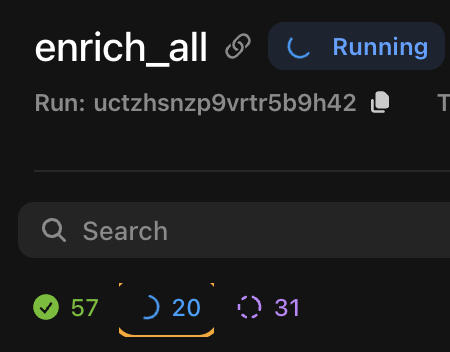

> **Scale note.** Every child task the driver awaits costs it some memory for tracking.
> For fan-outs beyond ~10k reviews, batch first (the micro-batching pattern in
> [05](./05-reusable-containers.ipynb)) and give the driver more memory than the workers.

## 3. Retries and timeouts

- `retries=3` → up to 4 attempts total. Applies to *task* failures (exceptions, OOM,
  node loss).
- `timeout` bounds two different things, and it pays to bound both:
  - `max_runtime`: how long an attempt may execute
  - `max_queued_time`: how long it may **wait for capacity** before Flyte gives up.
    This is your automatic detector for "the cluster has no free capacity": instead of a
    run silently pending for hours, you get a clear, attributable failure.

> 💬 **Discuss:** what should `max_queued_time` be for this customer's heaviest jobs?
> Which events in their environment (spot exhaustion, quota, autoscaler limits) would
> trip it, and who should hear about it when it fires?

In [32]:
from datetime import timedelta

from flyte import Timeout


@env.task(
    retries=3,
    timeout=Timeout(
        max_runtime=timedelta(minutes=10),
        max_queued_time=timedelta(minutes=5),
    ),
)
async def call_moderation_api(review: dict) -> dict:
    import random
    if random.random() < 0.2:
        raise ConnectionError(f"transient failure moderating review {review['id']}")
    return {**review, "moderation": "clean"}

In [33]:
# retries=3 recovers from the transient failures; some actions show a retry
# before succeeding (visible in the run timeline).
@env.task
async def moderate_all(reviews: List[dict]) -> List[dict]:
    out: List[dict] = []
    async for r in flyte.map.aio(call_moderation_api, reviews, return_exceptions=True):
        if isinstance(r, Exception):
            raise r
        out.append(r)
    return out


run = flyte.run(moderate_all, reviews=REVIEWS[:6])
print(run.url)
run.wait()
run.outputs()

> Building 1 image...

> Building image flyte for environment processing

✓ Built image for environment processing: ghcr.io/flyteorg/flyte:py3.12-v2.5.11

Output()

https://demo.hosted.unionai.cloud/v2/domain/development/project/davide/runs/ulzp6g5kwdskdjfxxn4g


Run 'ulzp6g5kwdskdjfxxn4g' completed successfully.

ActionOutputs(o0=[{'id': 0, 'product': 'headphones', 'stars': 2, 'text': 'review 0 about the headphones', 'moderation': 'clean'}, {'id': 1, 'product': 'air fryer', 'stars': 1, 'text': 'review 1 about the air fryer', 'moderation': 'clean'}, {'id': 2, 'product': 'espresso machine', 'stars': 5, 'text': 'review 2 about the espresso machine', 'moderation': 'clean'}, {'id': 3, 'product': 'espresso machine', 'stars': 3, 'text': 'review 3 about the espresso machine', 'moderation': 'clean'}, {'id': 4, 'product': 'espresso machine', 'stars': 5, 'text': 'review 4 about the espresso machine', 'moderation': 'clean'}, {'id': 5, 'product': 'trail shoes', 'stars': 1, 'text': 'review 5 about the trail shoes', 'moderation': 'clean'}])

The action recovered from a failure by retrying:

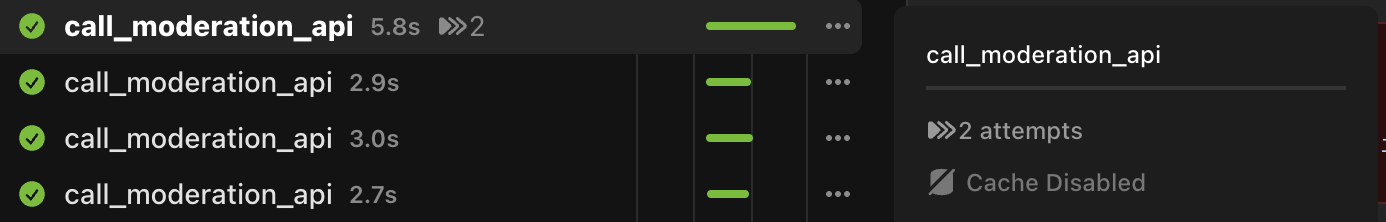

## 4. Recovering from OOM with more memory

The classic failure in data pipelines: input sizes vary 100×, so either you over-provision
everything or some shards OOM. In v2 the pipeline itself can catch
`flyte.errors.OOMError` and re-invoke with bigger resources: pay for the big pod only
when a skewed shard needs it:

In [39]:
import flyte.errors


@env.task
async def build_shard_index(reviews_in_shard: int) -> int:
    # Hold ~1kB per review in one contiguous buffer to simulate size-dependent memory use.
    # (A list of `b"x" * 1024` would NOT work: that expression is a compile-time constant,
    # so every element shares one object and the list costs ~pointers, not ~1kB each.)
    data = bytearray(reviews_in_shard * 1024)
    return len(data) // 1024


@env.task
async def resilient_index(reviews_in_shard: int) -> int:
    try:
        return await build_shard_index(reviews_in_shard=reviews_in_shard)
    except flyte.errors.OOMError:
        print("OOM at 1Gi, retrying this shard with 4Gi")
        return await build_shard_index.override(
            resources=flyte.Resources(cpu="1", memory="4Gi")
        )(reviews_in_shard=reviews_in_shard)

In [40]:
# Happy path: 100k "reviews" (~100MB) fits the 1Gi box and runs straight through.
#run = flyte.run(resilient_index, reviews_in_shard=100_000)
#print(run.url)
#run.wait()
#print(run.outputs())

# To WATCH the recovery: 2M reviews (~2GB) OOMs the 1Gi first attempt; the except
# branch retries at 4Gi and succeeds (~1-2 min; the first attempt fails on purpose).
run = flyte.run(resilient_index, reviews_in_shard=2_000_000)
print(run.url); run.wait(); print(run.outputs())

> Building 1 image...

> Building image flyte for environment processing

✓ Built image for environment processing: ghcr.io/flyteorg/flyte:py3.12-v2.5.11

Output()

https://demo.hosted.unionai.cloud/v2/domain/development/project/davide/runs/uqvlfgtfwr8sgqdxtcf5


Run 'uqvlfgtfwr8sgqdxtcf5' completed successfully.

ActionOutputs(o0=2000000)


This composes with `retries`: transient infrastructure failures use the retry budget,
while the OOM path changes the resources rather than retrying the same doomed
configuration. In operational reviews this is the cleanest way to separate **platform
errors** (node lost, image pull) from **user-code errors** (OOM at any size, exceptions).
More in [appendix B](./appendix/B-observability-and-debugging.md).

## 5. Checkpointing inside a task: `@flyte.trace`

Tasks are the unit of retry, but long tasks often have expensive internal phases. Our
moderation pass is that shape: **submit** a batch to the external API, then
**wait** for it to finish. `@flyte.trace` on an `async` helper makes each call a
**checkpoint**: on retry, completed calls are replayed from the record instead of
re-executed, so there are no double-submissions, and each call shows up in the UI timeline.

In [ ]:
@flyte.trace
async def submit_moderation_batch(ids: List[int]) -> str:
    # e.g. POST /batches to the moderation vendor; returns a job handle
    await asyncio.sleep(0.1)
    return f"job-{min(ids)}-{max(ids)}"


@flyte.trace
async def wait_for_moderation(job_id: str) -> int:
    # e.g. poll until the vendor finishes
    await asyncio.sleep(0.2)
    return len(job_id)


@env.task(retries=3)
async def moderate_corpus(review_ids: List[int]) -> int:
    job = await submit_moderation_batch(review_ids)     # checkpoint 1
    return await wait_for_moderation(job)               # checkpoint 2

In [ ]:
# The traced submit/wait helpers show up as steps inside the task's timeline.
run = flyte.run(moderate_corpus, review_ids=[r["id"] for r in REVIEWS[:6]])
print(run.url)
run.wait()
run.outputs()

If the pod dies while polling, the retry **skips re-submission**: the submit result is
replayed from the trace. Rules of thumb:

- Only `async def` helpers can be traced
- Trace non-deterministic/external calls; don't trace cheap pure functions
- Keep traced inputs/outputs small and serializable


**Story checkpoint:** the corpus is enriched in parallel and moderation is checkpointed
against retries. Next problem: we'll re-run this pipeline dozens of times while iterating
on features, without paying for the same work twice.

## Further reading

- Union docs: [Build tasks](https://www.union.ai/docs/v2/union/user-guide/task-programming/) (fan-out) · [Traces](https://www.union.ai/docs/v2/union/user-guide/task-programming/traces/)
- Next: [04-caching-and-reproducibility](./04-caching-and-reproducibility.ipynb)
- The pattern at 100k+ scale: [05-reusable-containers](./05-reusable-containers.ipynb)